In [1]:
from auxiliary_functions import *

In [ ]:
graph = nx.read_gexf("labeled_graph.gexf")
std_threshold = 0.5
NumberOfRandoms = 5000

In [ ]:
graphs = simplify_graph(graph, std_threshold)

# Generate null models for each subreddit graph
null_models = {}

for subreddit, subreddit_graph in graphs.items():
	# Create multiple randomized versions of each graph for statistical comparison
	null_models[subreddit] = [
		generate_null_model(subreddit_graph) 
		for _ in range(NumberOfRandoms)
	]

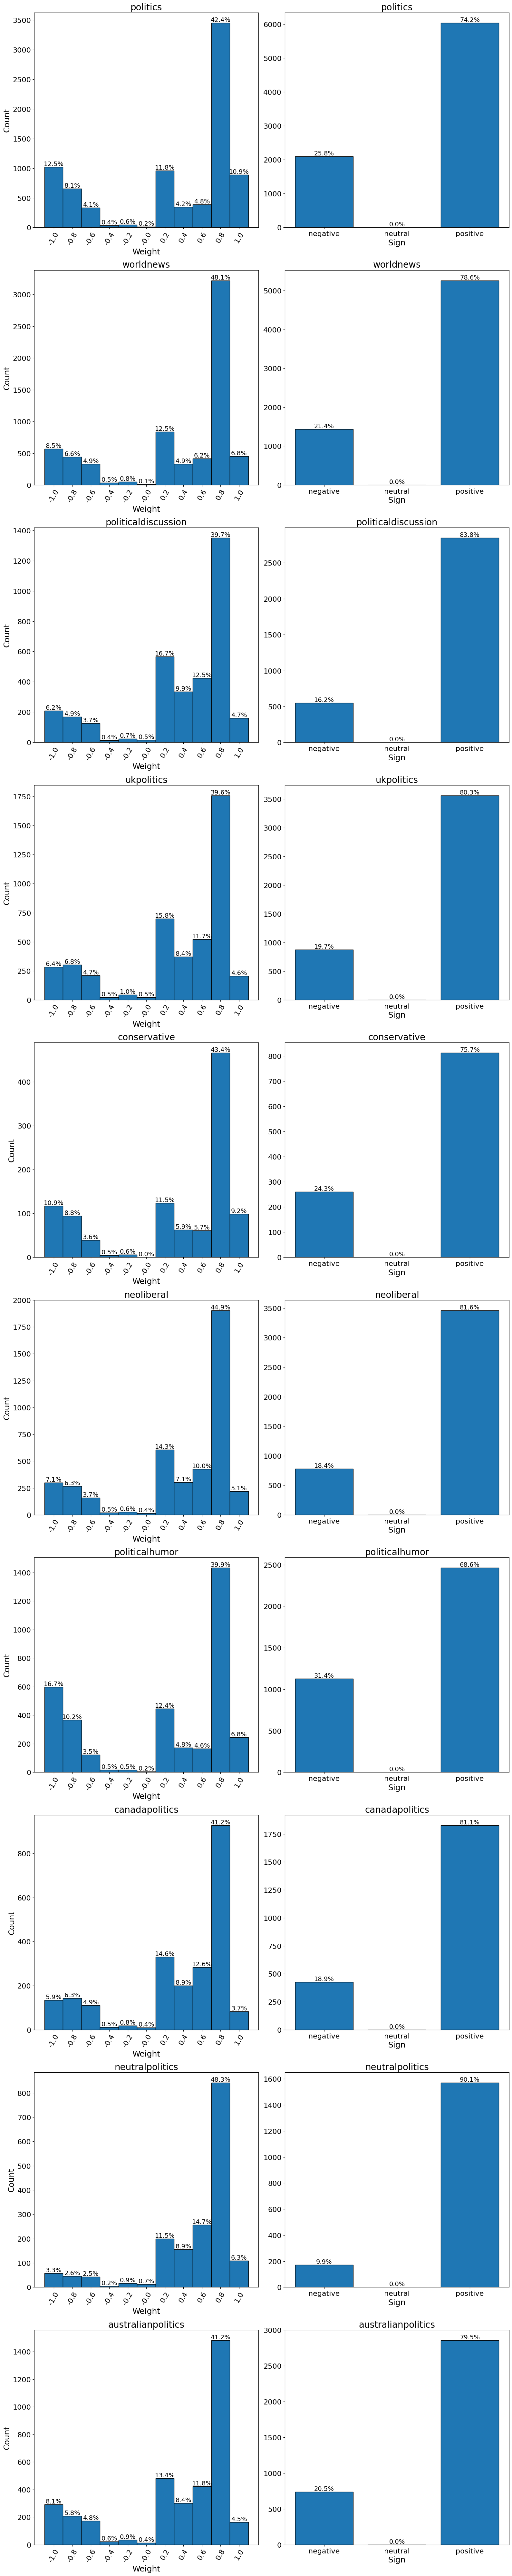

In [4]:
plot_weight_distribution(graphs)

In [5]:
triangles_graph = calculate_triangles_graph(graphs)

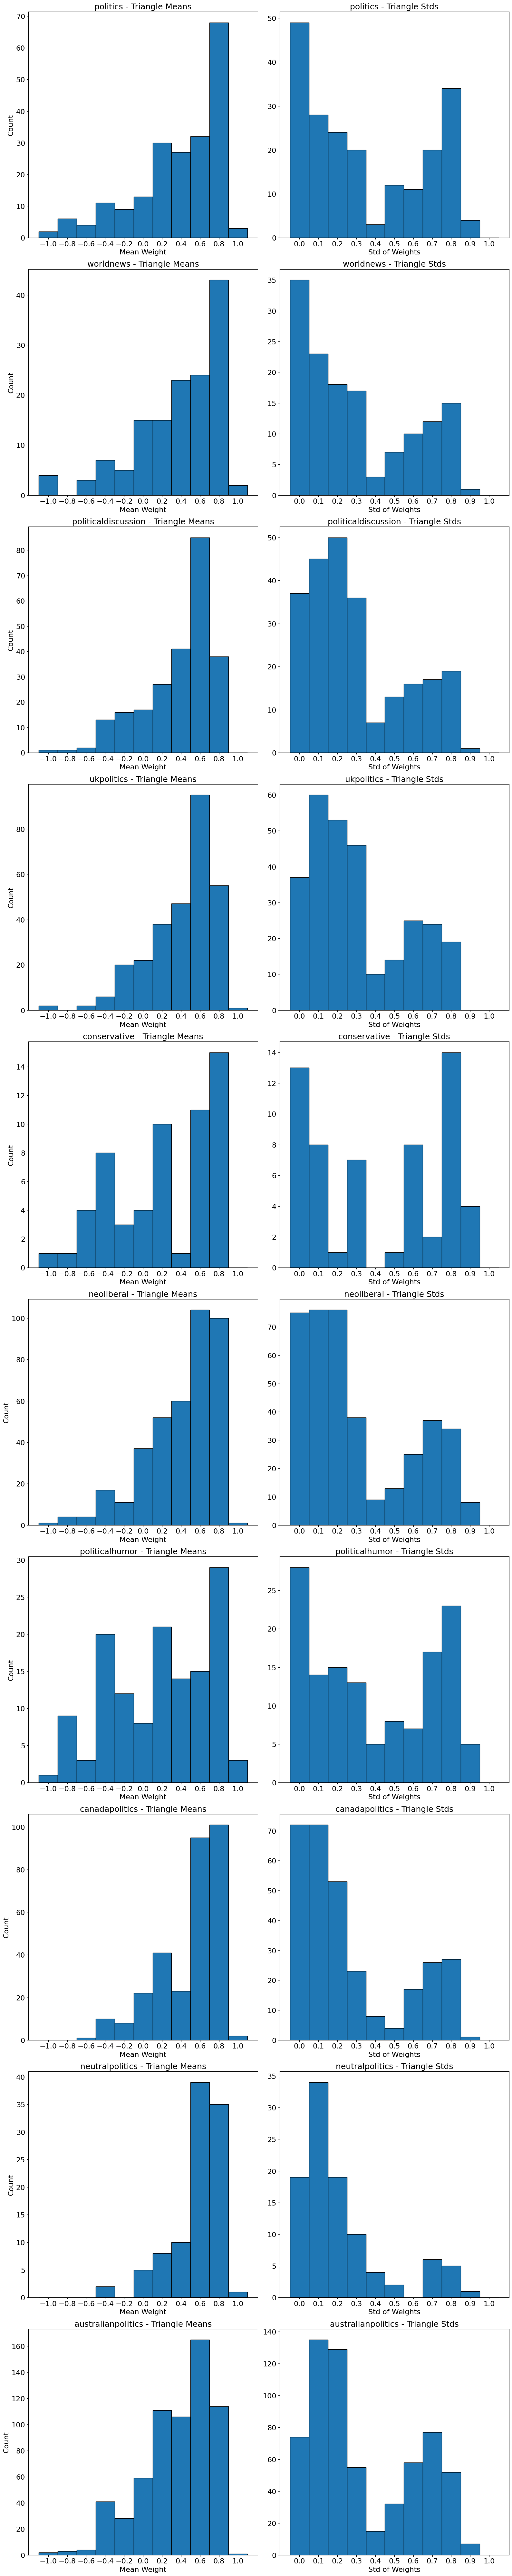

In [6]:
plot_triangle_distribution(graphs, triangles_graph)

In [7]:
df = number_of_triangles_per_type(graphs, triangles_graph)

df.to_csv('file.csv', index=True)

df

,0 pos edges,1 pos edge,2 pos edges,3 pos edges
politics,9,21,62,113
worldnews,6,10,40,85
politicaldiscussion,3,24,48,166
ukpolitics,3,24,67,194
conservative,2,14,15,27
neoliberal,6,29,100,256
politicalhumor,11,30,36,58
canadapolitics,0,16,68,219
neutralpolitics,0,3,15,82
australianpolitics,9,64,184,377


In [8]:
null_triangles = calculate_triangles_null_graph(graphs, null_models)

In [9]:
# IN DEVELOPMENT: NON_BINARY_METRIC

results_df = non_binary_metric(triangles_graph, null_triangles)
results_df

,subreddit,prod,avg_null,ratio
0,politics,0.061540,0.013229,4.651771
1,worldnews,0.089190,0.023659,3.769756
2,politicaldiscussion,0.081276,0.025788,3.151712
3,ukpolitics,0.076475,0.019591,3.903640
4,conservative,0.135232,0.017628,7.671242
5,neoliberal,0.083202,0.026331,3.159826
6,politicalhumor,0.098310,0.006004,16.373171
7,canadapolitics,0.128910,0.023562,5.470999
8,neutralpolitics,0.140683,0.082127,1.713002
9,australianpolitics,0.061621,0.019339,3.186365


In [10]:
calculate_balance_metrics(graphs, null_models, NumberOfRandoms)

KeyboardInterrupt: 

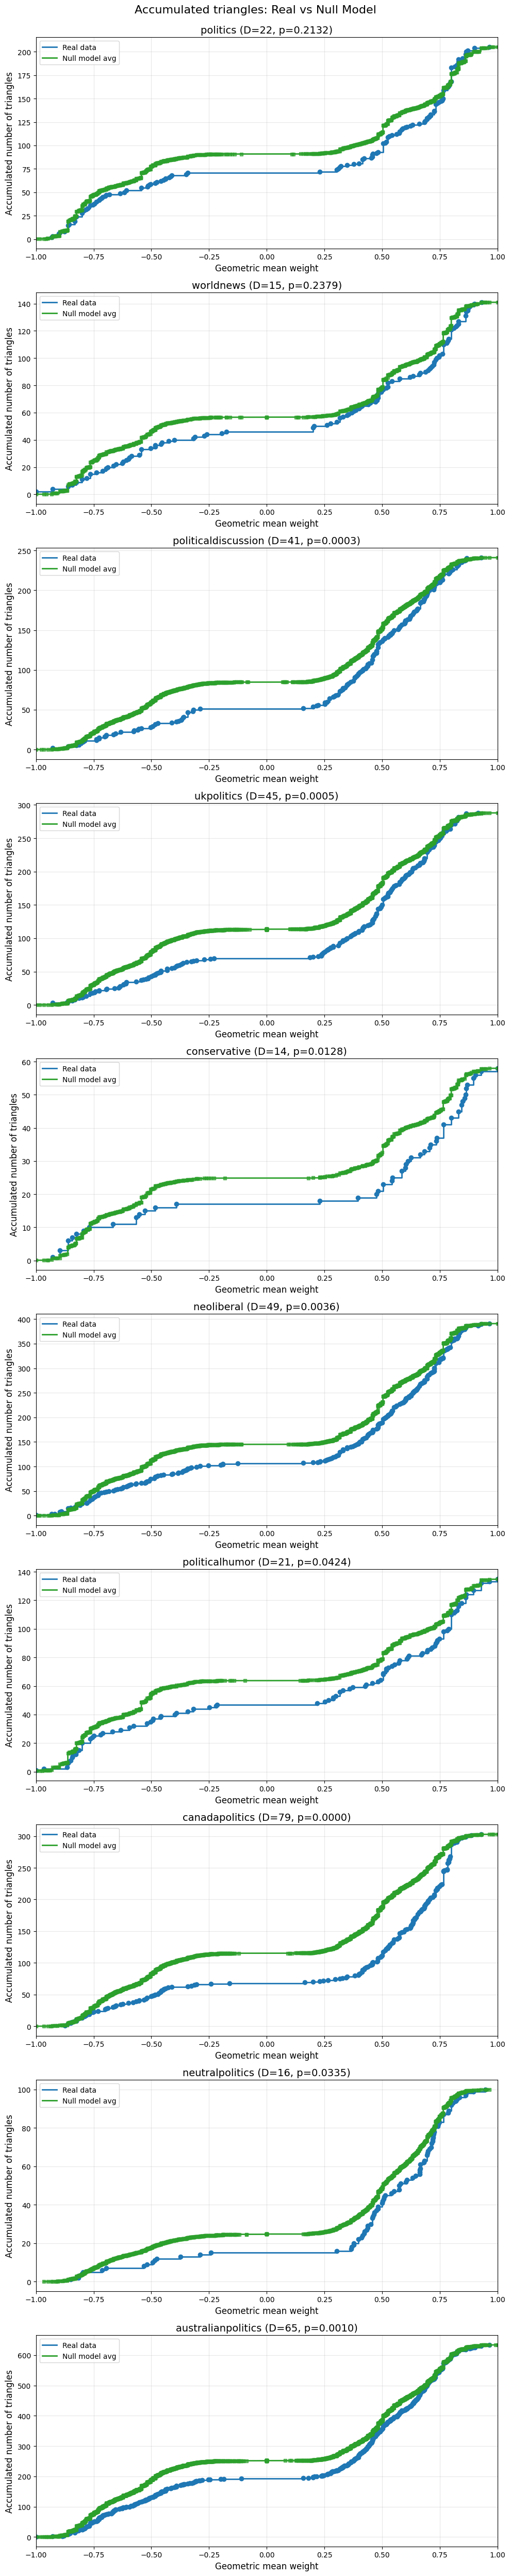


Kolmogorov-Smirnov Test Results:
politics                       | D =  22.0000 | p-value =   0.2132
worldnews                      | D =  15.0000 | p-value =   0.2379
politicaldiscussion            | D =  41.0000 | p-value =   0.0003
ukpolitics                     | D =  45.0000 | p-value =   0.0005
conservative                   | D =  14.0000 | p-value =   0.0128
neoliberal                     | D =  49.0000 | p-value =   0.0036
politicalhumor                 | D =  21.0000 | p-value =   0.0424
canadapolitics                 | D =  79.0000 | p-value =   0.0000
neutralpolitics                | D =  16.0000 | p-value =   0.0335
australianpolitics             | D =  65.0000 | p-value =   0.0010


In [ ]:
kolmogorov_smirnov(triangles_graph, null_triangles)